# YOLO Object Detection — PyTorch

This notebook loads a trained model and runs it on images. Change `image_path` in the last cell to test any image.

## Setup

Import dependencies, load the model architecture from `model.ipynb`, and restore the trained weights from `model1.pth`.

The model is set to `eval()` mode — this disables dropout and makes BatchNorm use its running statistics rather than batch statistics.

In [33]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

%pip install nbformat -q
%run model.ipynb

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# --- Load trained model ---
model = Model().to(device)
model.load_state_dict(torch.load('model1.pth', map_location=device))
model.eval()
print("Model loaded.")

Note: you may need to restart the kernel to use updated packages.
Model(
  (layers): ModuleList(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (Silu): SiLU()
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (Silu): SiLU()
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv(
      (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (batch_norm): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (Silu): SiLU()
    )
    (5): Conv(
      (conv): Conv2d(128, 64, kernel_size=(1, 1), str

## Prediction Pipeline

**Config:**
- `GRID_SIZE = 13` — the model divides the image into a 13×13 grid
- `CONF_THRESH` — minimum objectness score to keep a box (raise this if you're getting too many false positives)
- `NMS_THRESH` — boxes with IoU above this are considered duplicates and suppressed

**`iou(box1, box2)`** — computes Intersection over Union between two boxes. Used by NMS to measure overlap.

**`nms(boxes)`** — Non-Maximum Suppression. Sorts boxes by confidence, keeps the best, and removes any box that overlaps it by more than `NMS_THRESH`. Prevents the model drawing 20 boxes around the same object.

**`predict(image_path)`** — full pipeline: load image → resize to 416×416 → run model → decode grid predictions → apply NMS → return boxes.

In [34]:
GRID_SIZE   = 13
NUM_CLASSES = 80
CONF_THRESH = 0.9
NMS_THRESH  = 0.4   # boxes with IoU above this are suppressed
anchors     = torch.tensor([[0.28, 0.22], [0.38, 0.48]])

COCO_CLASSES = [
    'person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat',
    'dog','horse','sheep','cow','elephant','bear','zebra','giraffe','backpack',
    'umbrella','handbag','tie','suitcase','frisbee','skis','snowboard','sports ball',
    'kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket',
    'bottle','wine glass','cup','fork','knife','spoon','bowl','banana','apple',
    'sandwich','orange','broccoli','carrot','hot dog','pizza','donut','cake','chair',
    'couch','potted plant','bed','dining table','toilet','tv','laptop','mouse',
    'remote','keyboard','cell phone','microwave','oven','toaster','sink',
    'refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

def iou(box1, box2):
    # boxes are [xmin, ymin, xmax, ymax]
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

def nms(boxes, iou_thresh=NMS_THRESH):
    # Sort by confidence, highest first
    boxes = sorted(boxes, key=lambda x: x['conf'], reverse=True)
    kept = []
    while boxes:
        best = boxes.pop(0)
        kept.append(best)
        # Remove any box that overlaps too much with the best box
        boxes = [b for b in boxes if iou(best['box'], b['box']) < iou_thresh]
    return kept

def predict(image_path):
    image = Image.open(image_path).convert('RGB')
    orig_w, orig_h = image.size
    image_resized = image.resize((416, 416))
    tensor = torch.from_numpy(np.array(image_resized)).permute(2, 0, 1).float() / 255.0
    tensor = tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(tensor).squeeze(0).cpu()

    boxes_out = []

    for anchor_idx in range(2):
        offset = anchor_idx * 85
        anchor_w, anchor_h = anchors[anchor_idx]

        objectness = torch.sigmoid(predictions[offset + 0, :, :])
        pred_x     = torch.sigmoid(predictions[offset + 1, :, :])
        pred_y     = torch.sigmoid(predictions[offset + 2, :, :])
        pred_w     = predictions[offset + 3, :, :]
        pred_h     = predictions[offset + 4, :, :]
        pred_cls   = torch.sigmoid(predictions[offset + 5: offset + 85, :, :])

        for row in range(GRID_SIZE):
            for col in range(GRID_SIZE):
                conf = objectness[row, col].item()
                if conf < CONF_THRESH:
                    continue

                cx = (col + pred_x[row, col].item()) / GRID_SIZE
                cy = (row + pred_y[row, col].item()) / GRID_SIZE
                w  = torch.exp(pred_w[row, col]) * anchor_w
                h  = torch.exp(pred_h[row, col]) * anchor_h

                xmin = (cx - w / 2) * orig_w
                ymin = (cy - h / 2) * orig_h
                xmax = (cx + w / 2) * orig_w
                ymax = (cy + h / 2) * orig_h

                class_idx  = int(pred_cls[:, row, col].argmax())
                class_name = COCO_CLASSES[class_idx]
                class_conf = pred_cls[class_idx, row, col].item()

                boxes_out.append({
                    'box':        [xmin.item(), ymin.item(), xmax.item(), ymax.item()],
                    'conf':       conf,
                    'class':      class_name,
                    'class_conf': class_conf,
                })

    # Apply NMS to remove overlapping boxes
    boxes_out = nms(boxes_out)

    return image, boxes_out

## Run Inference

Change `image_path` to any image file. The output shows each detected object with its class label and confidence score.

Testing on: train2017/000000201756.jpg
Found 12 predictions above confidence threshold


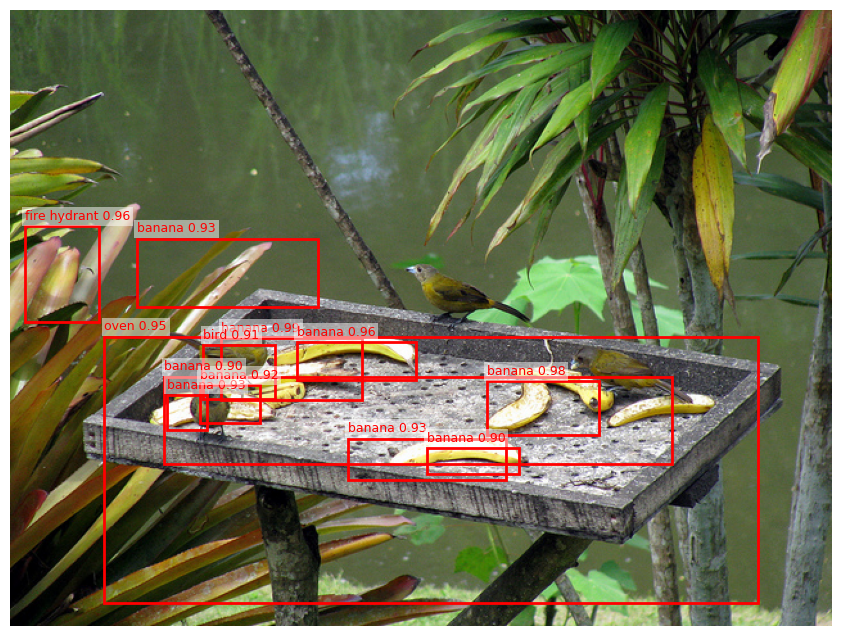

In [44]:
# --- Run on a random image from val2017 and display results ---
import random

val_dir    = "train2017"
image_path = os.path.join(val_dir, random.choice([
    f for f in os.listdir(val_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]))
print(f"Testing on: {image_path}")

image, boxes = predict(image_path)

print(f"Found {len(boxes)} predictions above confidence threshold")

fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(image)

for b in boxes:
    xmin, ymin, xmax, ymax = b['box']
    w = xmax - xmin
    h = ymax - ymin
    rect = patches.Rectangle((xmin, ymin), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(xmin, ymin - 5, f"{b['class']} {b['conf']:.2f}", color='red', fontsize=9,
            bbox=dict(facecolor='white', alpha=0.5, pad=2, edgecolor='none'))

ax.axis('off')
plt.show()